[h=0.01]: Solution may not be entirely stable ;)
[h=0.1]: Solution may not be entirely stable ;)
[h=0.5]: Solution may not be entirely stable ;)
[h=1.0]: Solution may not be entirely stable ;)


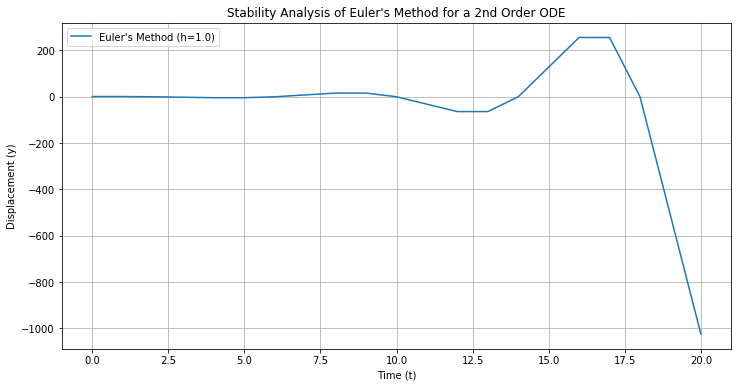

In [6]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k = 1.0 # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0] # Different step sizes to test stability
t_start = 0 # Start time
t_end = 20 # End time
y_0 = 1.0 # Initial displacement
v_0 = 0.0 # Initial velocity

# Function to apply Euler's Method for given step size
def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0
    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)
        
    # coeff matrix
    A = np.array([[1, h], [-h*k, 1]])
    eigenvalues, eigenvectors = np.linalg.eig(A)
    if (max([abs(i) for i in eigenvalues]) >= 1):
        print(f"[{h=}]: Solution may not be entirely stable ;)")
    else:
        print(f"[{h=}]: Solution is stable")
    
    return t_values, y_values

# Plot results for different step sizes
plt.figure(figsize=(12, 6))
for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)

plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()
